In [1]:
import pandas as pd

In [2]:
import scanpy as sc

In [3]:
import matplotlib.pyplot as plt

In [4]:
plt.rcParams['figure.figsize'] = (15,5)

In [5]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'  # Standardize font family
#plt.rcParams['font.sans-serif'] = ['Arial'] # Standardize font face

In [6]:
# Scanpy / matplotlib color palettes for diabetes-extended pancreas atlas
# All category names and hex colors are quoted for consistency.
# Disease-associated states with suffix _T1D, _T2D, and _aab are assigned high-contrast colors.
hpca_colors = {
  'Level_3' : {
    'Pancreatic Polypeptide Cell': '#8e44ad',
    'Alpha Cell': '#e67e22',
    'Beta Cell': '#1f77b4',     
    'Ductal Cell': '#17becf',
    'Stellate Cell': '#a6761d',
    'Delta Cell': '#2ca02c',
    'Mixed Endocrine Cell': '#7f7f7f',
    'Pericyte': '#8c564b',
    'T Cell': '#d62728',
    'Epsilon Cell': '#bcbd22',
    'Schwann Cell': '#9467bd',
    'Endothelial Cell': '#1b9e77',
    'Acinar Cell': '#66a61e',
    'Mast Cell': '#e7298a',
    'Fibroblast': '#b15928',
    'Macrophage': '#ff7f0e',
    'NK Cell': '#fb9a99',
    'Smooth Muscle Cell': '#6a3d9a',
    'Plasma Cell': '#cab2d6',
    'Adipocyte': '#fdbf6f',
    'Delta Cell_T1D': '#e53935',
    'Beta Cell_T1D': '#8e24aa',
    'Alpha Cell_T1D': '#d81b60',
    'Pancreatic Polypeptide Cell_T1D': '#ad1457',
    'Alpha Cell_T2D': '#00acc1',
    'Beta Cell_T2D': '#1e88e5',
    'Delta Cell_T2D': '#00e5ff',
    'Pancreatic Polypeptide Cell_T2D': '#1565c0',
    'Beta Cell_aab': '#ffb300',
    'Alpha Cell_aab': '#fdd835',
    'Delta Cell_aab': '#ff8f00',
    'Pancreatic Polypeptide Cell_aab': '#f57f17',
    'B Cell': '#e91e63',
  },
  'Dataset' : {
    'GSE101207_remapped': '#1f77b4',
    'GSE198623': '#ff7f0e',
    'GSE84133_remapped': '#2ca02c',
    'GSE183568': '#d62728',
    'Karakose': '#9467bd',
    'Tabula_Sapiens': '#8c564b',
    'GSE150724': '#e377c2',
    'GSE114297_remapped': '#7f7f7f',
    'HPAP': '#bcbd22',
    'Espace': '#17becf',
    'charite_snRNA': '#393b79',
    'Jimenez': '#637939',
    'GSE251913': '#8c6d31'
  },
  'suspension_type' : { 
    'cell': '#4c78a8',
    'nucleus': '#f58518',
  },
  'Level_4_extension_diabetes_simplified' : { 
    'Pancreatic Polypeptide Cell': '#562097',
    'Alpha Cell: GCG_Mid': '#974d20',
    'Beta Cell: Secretory Granules': '#206b97',
    'Alpha Cell: GCG_High': '#b26722',
    'Ductal Cell: Oxidative Stress': '#20978a',
    'Alpha Cell: Interferon Response': '#cf8822',
    'Alpha Cell: High OxPhos': '#e16f2c',
    'Beta Cell: Immediate Early Activation': '#216bb0',
    'Beta Cell: Interferon Response': '#2166c9',
    'Ductal Cell: CFTR Transport': '#23b8b8',
    'Beta Cell: INS_Mid, IAPP_High': '#239ae0',
    'Beta Cell: Oxidative Stress': '#4591d7',
    'Beta Cell: Dedifferentiation-like': '#568fdf',
    'Alpha Cell: Dedifferentiation-like': '#da9250',
    'Stellate Cell: Quiescent': '#973020',
    'Alpha Cell: ER Stress': '#e2ae65',
    'Delta Cell': '#289720',
    'Pancreatic Polypeptide Cell: ER Stress': '#8026c8',
    'Beta Cell: INS_Low': '#69b7e6',
    'Alpha-Beta-Delta Cell': '#e9a37a',
    'Alpha Cell: Mature Identity': '#efbe90',
    'Alpha Cell: Oxidative Stress': '#a36e23',
    'Alpha Cell: GCG_Low': '#be5d24',
    'Beta Cell: ER Stress': '#7cb6ec',
    'Ductal Cell: Centroacinar Cell': '#24c7db',
    'Delta Cell: High OxPhos': '#25c22b',
    'Delta Cell: Oxidative Stress': '#38de51',
    'Ductal Cell: EMT Transition': '#3fe4d2',
    'Ductal Cell: Injury Reactive': '#68dfdf',
    'Beta Cell: High OxPhos': '#98b9e9',
    'Beta Cell: Ion Channel Activity': '#1f73a5',
    'Alpha Cell: Proliferating': '#db7c24',
    'Ductal Cell: Proliferating': '#83dde8',
    'Beta Cell: Proliferating': '#1f72be',
    'Pancreatic Polypeptide Cell: Oxidative Stress': '#ac43e0',
    'Delta Cell: ER Stress': '#68e85e',
    'Ductal Cell: Mucin Secretion': '#9fefe6',
    'Pancreatic Polypeptide Cell: High OxPhos': '#a66eea',
    'Pericyte': '#d75228',
    'Pancreatic Polypeptide Cell: Interferon Response': '#cba3eb',
    'T Cell: CD8+': '#97203b',
    'Pancreatic Polypeptide Cell: Proliferating': '#8121b1',
    'Delta Cell: Interferon Response': '#8fe792',
    'Epsilon Cell': '#d7c142',
    'Beta Cell: Mature Identity': '#1f6bd8',
    'Ductal Cell: Interferon Response': '#19b1b1',
    'Delta Cell: Proliferating': '#21ae36',
    'Schwann Cell': '#e58f61',
    'Ductal Cell': '#2ab3c3',
    'Endothelial Cell: Vascular': '#209760',
    'Delta Cell: Dedifferentiation-like': '#30db24',
    'Beta Cell: INS_High': '#3b9cd5',
    'Beta Cell: INS_Mid': '#4c97dd',
    'Stellate Cell: Activated': '#f1a89d',
    'Acinar Cell: Quiescent': '#699720',
    'Mast Cell': '#972220',
    'Alpha Cell: GCG_Low, POU6F2_High': '#e39d39',
    'Acinar Cell: Digestive Secretion': '#6fbb23',
    'Acinar Cell: Oxidative Stress': '#6fdc2a',
    'Acinar Cell: CBS': '#a7e547',
    'Acinar Cell: Transitional': '#aae172',
    'Ductal Cell: SLC4A4_pos': '#37d9c8',
    'Fibroblast: CAF-like': '#b54927',
    'Ductal Cell: Ionocyte Like': '#52e3e3',
    'Acinar Cell: Interferon Response': '#b3ea90',
    'Acinar Cell: ADM Plasticity': '#75ae1d',
    'Acinar Cell: Proliferating': '#79d41e',
    'Acinar Cell: Injury Response': '#7cd742',
    'Macrophage: Proliferating': '#d94834',
    'Beta Cell: INS_High, IAPP_Low': '#5e95e4',
    'Acinar Cell: Idling': '#aee15f',
    'Macrophage: Activated': '#e9937a',
    'Acinar Cell': '#b3ea7d',
    'Endothelial Cell: Lymphatic': '#a1edd2',
    'Macrophage: Stressed': '#c61e1c',
    'Endothelial Cell': '#43e0b8',
    'Ductal Cell: PanIN': '#6eddea',
    'Treg: Resting': '#be2436',
    'Macrophage: Neural': '#dc6b5c',
    'Ductal Cell: Immature': '#94e8df',
    'Macrophage: Tissue resident': '#edb2a1',
    'Alpha Cell: GCG_High, IRX2_High': '#dc8c5c',
    'T Cell: Naive CD4+': '#dd3032',
    'B Cell': '#e75274',
    'Treg: Activated': '#e47f8b',
    'NK Cell': '#eda1a2',
    'T Cell: CM CD4+': '#b01d3e',
    'Smooth Muscle Cell': '#dc7b47',
    'Plasma Cell': '#d91f35',
    'Acinar Cell: PanIN': '#bef19d',
    'T Cell: Peripheral helper': '#d84a4c',
    'Treg: Proliferating': '#e36b86',
    'T Cell: EM CD4+': '#ec8c98',
    'Adipocyte': '#ea8e80',
    'Delta Cell_T1D': '#e53935',
    'Beta Cell_T1D': '#8e24aa',
    'Alpha Cell_T1D': '#d81b60',
    'Pancreatic Polypeptide Cell_T1D': '#ad1457',
    'Alpha Cell_T2D': '#00acc1',
    'Beta Cell_T2D': '#1e88e5',
    'Delta Cell_T2D': '#00e5ff',
    'Pancreatic Polypeptide Cell_T2D': '#1565c0',
    'Beta Cell_aab': '#ffb300',
    'Alpha Cell_aab': '#fdd835',
    'Delta Cell_aab': '#ff8f00',
    'Pancreatic Polypeptide Cell_aab': '#f57f17',
}
}

In [7]:
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199


In [8]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream/2026_final_object_healthy_hierarchy.h5ad')

In [9]:
adata.obs.suspension_type.value_counts()/len(adata.obs_names)

suspension_type
nucleus    0.676922
cell       0.323078
Name: count, dtype: float64

In [10]:

((pd.crosstab(adata.obs.Level_4_refined_desc, adata.obs.suspension_type).T/adata.obs.Level_4_refined_desc.value_counts()).T).sort_values(by='nucleus', ascending=False)

suspension_type,cell,nucleus
Level_4_refined_desc,,
Adipocyte,0.000000,1.000000
T Cell [EM CD4+],0.000000,1.000000
"Beta Cell [Secretion-High: INS_High, MAFA_Low]",0.002801,0.997199
Acinar Cell-CBS,0.002999,0.997001
Acinar Cell-i,0.006550,0.993450
"Acinar Cell [PanIN, LGR5_pos]",0.007348,0.992652
Acinar Cell-s,0.013096,0.986904
Smooth Muscle Cell,0.018462,0.981538
Fibroblast [CAF-like],0.018585,0.981415


In [11]:
metadata = adata.obs.groupby(adata.obs.donor_id).first()[['Dataset', 'sex--cell_ontology_term_id', 'suspension_type', 'preparation']]

/tmp/ipykernel_2545533/2732954595.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metadata = adata.obs.groupby(adata.obs.donor_id).first()[['Dataset', 'sex--cell_ontology_term_id', 'suspension_type', 'preparation']]


In [12]:
ct_proportions = pd.crosstab(adata.obs.Level_4_refined_desc, adata.obs.ID).T/adata.obs.ID.value_counts()

In [13]:
ct_proportions_level_3 = pd.crosstab(adata.obs.Level_3, adata.obs.donor_id)/adata.obs.donor_id.value_counts()

In [14]:
ct_proportions_level_3 = ct_proportions_level_3.T

In [15]:
ct_proportions_level_3['Dataset'] = metadata['Dataset']

In [16]:
ct_proportions_level_3['suspension_type'] = metadata['suspension_type']

In [17]:
ct_proportions_level_3['preparation'] = metadata['preparation']

In [18]:
ct_proportions_level_3 = ct_proportions_level_3.sort_values(by=['preparation', 'Dataset'])

In [ ]:
#ct_proportions_level_3 = ct_proportions_level_3.set_index(['preparation', 'Dataset', 'empty_id'])

KeyError: "None of ['empty_id'] are in the columns"

In [23]:
df = ct_proportions_level_3.iloc[:,-3:]

In [24]:
df_props = ct_proportions_level_3.iloc[:,:-3]

In [25]:
df_props

Level_3,Acinar Cell,Adipocyte,Alpha Cell,Beta Cell,Delta Cell,Ductal Cell,Endothelial Cell,Epsilon Cell,Fibroblast,Macrophage,Mast Cell,Mixed Endocrine Cell,NK Cell,Pancreatic Polypeptide Cell,Pericyte,Plasma Cell,Schwann Cell,Smooth Muscle Cell,Stellate Cell,T Cell,B Cell
donor_id,,,,,,,,,,,,,,,,,,,,,
H1,0.078818,0.000000,0.142857,0.405583,0.100164,0.068966,0.073071,0.006568,0.000000,0.004926,0.004105,0.000821,0.000000,0.032841,0.040230,0.000000,0.000821,0.000000,0.039409,0.000821,0.000000
H2,0.057981,0.000000,0.400143,0.204724,0.073729,0.117394,0.013601,0.001432,0.000000,0.005011,0.006442,0.001432,0.000000,0.055118,0.007158,0.000000,0.002863,0.000000,0.051539,0.001432,0.000000
H3,0.247551,0.000000,0.319399,0.195624,0.041150,0.101894,0.021881,0.000327,0.003592,0.002939,0.002286,0.000653,0.000000,0.019922,0.012410,0.000000,0.000000,0.000000,0.029719,0.000653,0.000000
H4,0.052381,0.000000,0.209524,0.391429,0.077143,0.161905,0.006667,0.000952,0.000000,0.006667,0.000952,0.000000,0.000000,0.052381,0.000952,0.000000,0.000952,0.000000,0.038095,0.000000,0.000000
Non_diabetic_donor_1,0.029520,0.000000,0.394834,0.215867,0.038745,0.219557,0.023985,0.000000,0.000000,0.000000,0.000000,0.001845,0.000000,0.018450,0.012915,0.000000,0.001845,0.000000,0.036900,0.005535,0.000000
Non_diabetic_donor_2,0.004525,0.000000,0.495475,0.282805,0.031674,0.056561,0.011312,0.000000,0.000000,0.000000,0.000000,0.038462,0.000000,0.006787,0.038462,0.000000,0.000000,0.000000,0.033937,0.000000,0.000000
Non_diabetic_donor_3,0.000679,0.000000,0.455882,0.324208,0.030995,0.017873,0.000452,0.001131,0.000000,0.000226,0.000000,0.034163,0.000000,0.060407,0.008371,0.000000,0.000452,0.000000,0.065158,0.000000,0.000000
Non_diabetic_donor_4,0.001458,0.000000,0.327988,0.487974,0.050656,0.067055,0.000729,0.001822,0.000000,0.000000,0.000364,0.016764,0.000000,0.036079,0.003644,0.000000,0.000364,0.000000,0.005102,0.000000,0.000000
Non_diabetic_donor_5,0.000813,0.000000,0.483543,0.305973,0.040228,0.039821,0.003251,0.002844,0.001219,0.000000,0.000406,0.038196,0.000000,0.018285,0.021130,0.000000,0.000000,0.000000,0.044291,0.000000,0.000000


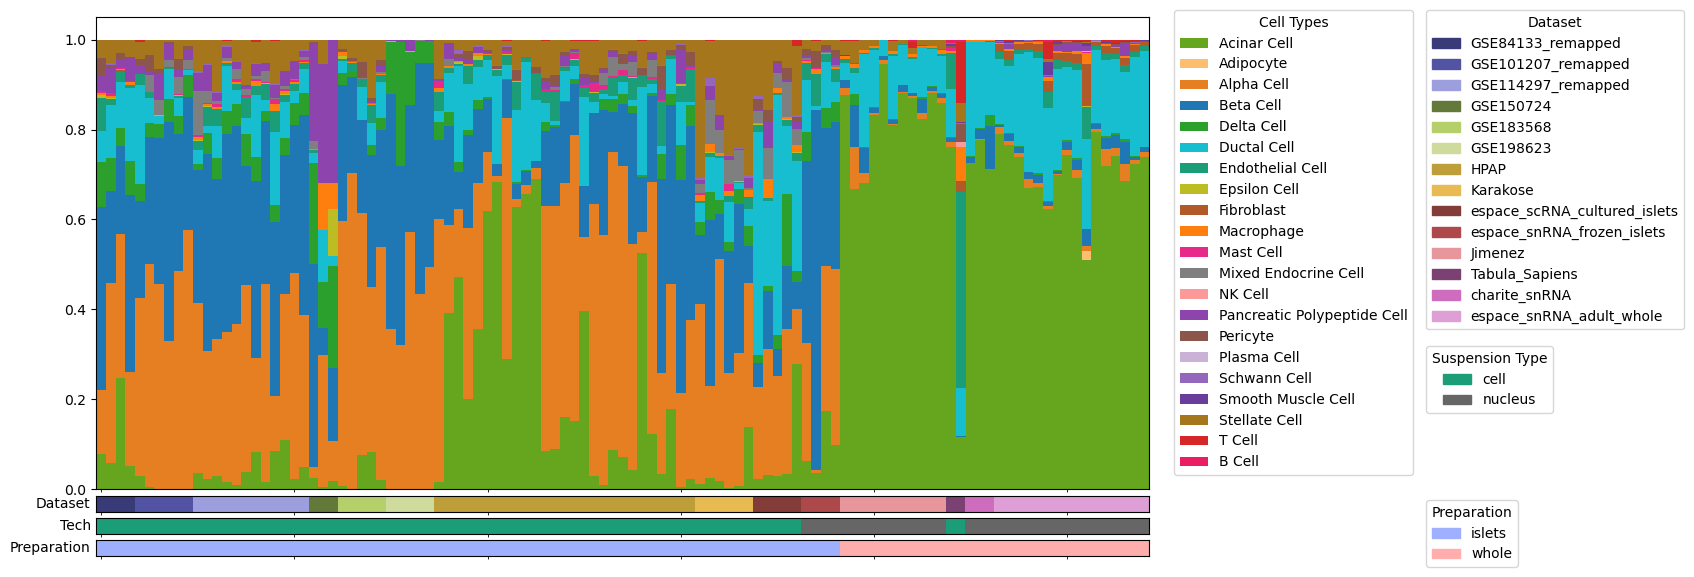

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Set up the figure ---
fig, axes = plt.subplots(
    nrows=4, ncols=1, figsize=(18, 7), 
    gridspec_kw={'height_ratios': [15, 0.5, 0.5, 0.5], 'hspace': 0.05},
    sharex=True
)

# --- Plot 1: The Stacked Bar Plot (Top) ---
level_3_colors = [hpca_colors['Level_3'][col] for col in df_props.columns]
df_props.plot.bar(stacked=True, ax=axes[0], width=1, legend=False, color=level_3_colors)

axes[0].set_xlim(-0.5, len(df_props) - 0.5) 
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', bottom=False, labelbottom=False)

# --- Plot 2: Dataset Track (Middle) ---
dataset_codes, dataset_uniques = pd.factorize(df['Dataset'])
n_datasets = len(dataset_uniques)

# Changed to 'tab20b' which holds up to 20 unique colors. 
# (If you have >20 datasets, use this instead: cmap_dataset = plt.colormaps['turbo'].resampled(n_datasets) )
cmap_dataset = plt.get_cmap('tab20b', n_datasets) 

axes[1].imshow([dataset_codes], aspect='auto', cmap=cmap_dataset, vmin=-0.5, vmax=n_datasets-0.5)
axes[1].set_yticks([]) 
axes[1].set_ylabel('Dataset', rotation=0, ha='right', va='center')

# --- Plot 3: Suspension Type Track (Bottom) ---
tech_codes, tech_uniques = pd.factorize(df['suspension_type'])
n_tech = len(tech_uniques)

cmap_tech = plt.get_cmap('Dark2', n_tech)
axes[2].imshow([tech_codes], aspect='auto', cmap=cmap_tech, vmin=-0.5, vmax=n_tech-0.5)
axes[2].set_yticks([])
axes[2].set_ylabel('Tech', rotation=0, ha='right', va='center')
axes[2].set_xticks([])
axes[2].set_xticklabels([])
axes[2].set_xlabel('')

# --- Plot 4: Preparation Track (Bottom) ---
preparation_codes, preparation_uniques = pd.factorize(df['preparation'])
n_preparation = len(preparation_uniques)

cmap_preparation = plt.get_cmap('berlin', n_preparation)
axes[3].imshow([preparation_codes], aspect='auto', cmap=cmap_preparation, vmin=-0.5, vmax=n_preparation-0.5)
axes[3].set_yticks([])
axes[3].set_ylabel('Preparation', rotation=0, ha='right', va='center')
axes[3].set_xticks([])
axes[3].set_xticklabels([])
axes[3].set_xlabel('')

# =========================================
# --- Creating and Placing the Legends ---
# =========================================

# 1. Main Cell Types Legend
handles_cells, labels_cells = axes[0].get_legend_handles_labels()
leg_cells = fig.legend(  # Note: Changed from axes[0].legend to fig.legend
    handles_cells, labels_cells, 
    title='Cell Types', 
    loc='upper left',
    # Place at exactly 72% across the figure width, 90% up the height
    bbox_to_anchor=(0.72, 0.9), 
    bbox_transform=fig.transFigure 
)

# 2. Dataset Legend
handles_dataset = [mpatches.Patch(color=cmap_dataset(i), label=dataset_uniques[i]) for i in range(n_datasets)]
leg_dataset = fig.legend(
    handles_dataset, dataset_uniques, 
    title='Dataset', 
    loc='upper left',
    # Place at exactly 85% across the figure width
    bbox_to_anchor=(0.86, 0.9), 
    bbox_transform=fig.transFigure
)

# 3. Suspension Tech Legend
handles_tech = [mpatches.Patch(color=cmap_tech(i), label=tech_uniques[i]) for i in range(n_tech)]
leg_tech = fig.legend(
    handles_tech, tech_uniques, 
    title='Suspension Type', 
    loc='upper left',
    # Aligned with Dataset legend (85% width), but lower down (40% height)
    bbox_to_anchor=(0.86, 0.42), 
    bbox_transform=fig.transFigure
)

# 3. Suspension Tech Legend
handles_preparation = [mpatches.Patch(color=cmap_preparation(i), label=preparation_uniques[i]) for i in range(n_preparation)]
leg_preparation = fig.legend(
    handles_preparation, preparation_uniques, 
    title='Preparation', 
    loc='upper left',
    # Aligned with Dataset legend (85% width), but lower down (40% height)
    bbox_to_anchor=(0.86, 0.2), 
    bbox_transform=fig.transFigure
)

# Force the main plots to stop exactly at 70% of the window width, 
# leaving a massive 30% strictly reserved for your legends.
fig.subplots_adjust(right=0.71)


plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_technology_mixing/id_proportions.svg')
plt.show()

In [110]:
adata.obs.Level_2.value_counts()

Level_2
Epithelial - Exocrine           569635
Epithelial - Endocrine          273764
Epithelial - Mixed Exocrine      77027
Stromal                          43742
Endothelial Cell                 20825
Immune - Myeloid                  7488
Epithelial - Mixed Endocrine      4909
Immune - Lymphoid                 3851
Neural / Glial                     887
Name: count, dtype: int64

In [121]:
adata.obs.Level_2.unique()

['Epithelial - Endocrine', 'Epithelial - Exocrine', 'Stromal', 'Epithelial - Mixed Endocrine', 'Immune - Lymphoid', 'Neural / Glial', 'Endothelial Cell', 'Immune - Myeloid', 'Epithelial - Mixed Exocrine']
Categories (9, object): ['Endothelial Cell', 'Epithelial - Endocrine', 'Epithelial - Exocrine', 'Epithelial - Mixed Endocrine', ..., 'Immune - Lymphoid', 'Immune - Myeloid', 'Neural / Glial', 'Stromal']

In [116]:
adata.obs.Level_3.value_counts()

Level_3
Acinar Cell                    501563
Ductal Cell                    145099
Alpha Cell                     139317
Beta Cell                      104655
Stellate Cell                   27375
Endothelial Cell                20825
Delta Cell                      17162
Pancreatic Polypeptide Cell     11613
Fibroblast                       9012
Macrophage                       6436
Pericyte                         5395
Mixed Endocrine Cell             4909
T Cell                           3663
Smooth Muscle Cell               1418
Mast Cell                        1052
Epsilon Cell                     1017
Schwann Cell                      887
Adipocyte                         542
NK Cell                           122
Plasma Cell                        66
Name: count, dtype: int64

In [120]:
adata[adata.obs.Level_2 == 'Immune - Myeloid'].obs.Level_4_refined.value_counts()

Level_4_refined
Macrophage - activated          2388
Macrophage - tissue resident    2291
Mast Cell                       1052
Macrophage - stressed            760
Macrophage - proliferating       522
Macrophage - neural              475
Name: count, dtype: int64

In [29]:
del adata